<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/BA283_Schematic_Construction_Schemdraw_Graphviz_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

# BA283 subcircuit schematic construction with Schemdraw and Graphviz

This notebook constructs a circuit schematic containing lumped element components. Graphviz generates the stage placement and connectivity audit. Schemdraw renders the final electrical schematic.

In [ ]:
# Install the system Graphviz renderer and Python packages.
!apt-get -qq update
!apt-get -qq install -y graphviz
!python -m pip -q install uv
!uv pip install --system -q schemdraw==0.23 graphviz==0.21 pillow matplotlib

The control knobs are grouped at the top of the code cell. Set `SHOW_TOPOLOGY_GRAPH` to `False` to suppress the Graphviz diagnostic output.

In [6]:
"""Construct BA283 subcircuit schematic containing BC184C transistors with Schemdraw.

Graphviz supplies a coarse left-to-right stage layout and a topology audit.
Schemdraw supplies the electrical symbols, junctions, labels, and final PNG.
The drawing uses manually tuned coordinates derived from the reference image.
"""

from collections.abc import Iterable, Sequence
from dataclasses import dataclass
from pathlib import Path
from typing import Final

import graphviz
import matplotlib as mpl
import schemdraw
import schemdraw.elements as elm
from PIL import Image, ImageOps


# -----------------------------------------------------------------------------
# Control knobs
# -----------------------------------------------------------------------------
OUTPUT_DIR: Final[Path] = Path("/content") if Path("/content").exists() else Path("/mnt/data")
SCHEMATIC_PNG: Final[Path] = OUTPUT_DIR / "bc184c_schematic_reconstruction.png"
TOPOLOGY_PNG_STEM: Final[Path] = OUTPUT_DIR / "bc184c_topology_graph"
DPI: Final[int] = 250
LINE_WIDTH: Final[float] = 1.75
FONT_SIZE: Final[float] = 9.5
LABEL_FONT_SIZE: Final[float] = 9.0
TITLE_FONT_SIZE: Final[float] = 11.0
FONT_FAMILY: Final[str] = "DejaVu Sans"
SHOW_TOPOLOGY_GRAPH: Final[bool] = True
SHOW_SCHEMATIC: Final[bool] = True
MATCH_REFERENCE_PIXEL_SIZE: Final[bool] = True

# Manual geometry in Schemdraw units.
X_LEFT: Final[float] = 0.40
X_RIGHT: Final[float] = 24.30
Y_TOP: Final[float] = 12.00
Y_GND: Final[float] = 0.00
Y_SIGNAL: Final[float] = 6.25
Y_P: Final[float] = 8.25
Y_FEEDBACK_UPPER: Final[float] = 4.45
Y_FEEDBACK_LOWER: Final[float] = 2.05
Y_T: Final[float] = 2.05

# Reference-image dimensions recorded during visual analysis.
REFERENCE_WIDTH_PX: Final[int] = 2048
REFERENCE_HEIGHT_PX: Final[int] = 1137

mpl.rcParams["figure.dpi"] = DPI
mpl.rcParams["savefig.dpi"] = DPI
mpl.rcParams["font.family"] = FONT_FAMILY
schemdraw.use("matplotlib")


@dataclass(frozen=True)
class TerminalRef:
    """One component terminal attached to a named electrical net."""

    component: str
    pin: str


# Bipartite netlist used for Graphviz connectivity auditing.
NETLIST: Final[dict[str, tuple[TerminalRef, ...]]] = {
    "N": (
        TerminalRef("R11", "1"),
        TerminalRef("R13", "1"),
        TerminalRef("TR6", "C"),
        TerminalRef("N_LEFT", "1"),
        TerminalRef("N_RIGHT", "1"),
    ),
    "V": (
        TerminalRef("R9", "2"),
        TerminalRef("C11", "2"),
        TerminalRef("C12", "2"),
        TerminalRef("C13", "2"),
        TerminalRef("R15", "2"),
        TerminalRef("R16", "2"),
        TerminalRef("C16", "2"),
        TerminalRef("R18", "2"),
        TerminalRef("R19", "2"),
        TerminalRef("R20", "2"),
        TerminalRef("V_LEFT", "1"),
        TerminalRef("V_RIGHT", "1"),
    ),
    "U": (
        TerminalRef("U", "1"),
        TerminalRef("R9", "1"),
        TerminalRef("C8", "-")
    ),
    "B4": (
        TerminalRef("C8", "+"),
        TerminalRef("R10", "1"),
        TerminalRef("C9", "1"),
        TerminalRef("C10", "1"),
        TerminalRef("TR4", "B"),
    ),
    "A": (
        TerminalRef("R11", "2"),
        TerminalRef("R12", "1"),
        TerminalRef("C12", "+"),
    ),
    "C4_B5": (
        TerminalRef("R12", "2"),
        TerminalRef("C9", "2"),
        TerminalRef("C11", "1"),
        TerminalRef("TR4", "C"),
        TerminalRef("TR5", "B"),
    ),
    "F": (
        TerminalRef("TR4", "E"),
        TerminalRef("C10", "2"),
        TerminalRef("R10", "2"),
        TerminalRef("R14", "2"),
        TerminalRef("C13", "+"),
        TerminalRef("R15", "1"),
        TerminalRef("R17", "2"),
        TerminalRef("R18", "1"),
        TerminalRef("C17", "+"),
    ),
    "C5_B6": (
        TerminalRef("R13", "2"),
        TerminalRef("TR5", "C"),
        TerminalRef("TR6", "B"),
    ),
    "E5": (
        TerminalRef("TR5", "E"),
        TerminalRef("R14", "1"),
        TerminalRef("C14", "+"),
    ),
    "S": (
        TerminalRef("C14", "-"),
        TerminalRef("R16", "1"),
        TerminalRef("S", "1"),
    ),
    "E6": (
        TerminalRef("TR6", "E"),
        TerminalRef("C15", "+"),
        TerminalRef("R17", "1"),
        TerminalRef("C16", "1"),
    ),
    "P": (
        TerminalRef("C15", "-"),
        TerminalRef("R20", "1"),
        TerminalRef("P", "1"),
    ),
    "T": (
        TerminalRef("C17", "-"),
        TerminalRef("R19", "1"),
        TerminalRef("T", "1"),
    ),
}


COMPONENT_GROUPS: Final[dict[str, str]] = {
    "R9": "input",
    "C8": "input",
    "R10": "q4",
    "C9": "q4",
    "C10": "q4",
    "R11": "q4",
    "R12": "q4",
    "C11": "q4",
    "C12": "q4",
    "TR4": "q4",
    "R13": "q5",
    "TR5": "q5",
    "R14": "q5",
    "C13": "q5",
    "R15": "q5",
    "C14": "q5",
    "R16": "q5",
    "TR6": "q6",
    "R17": "q6",
    "R18": "q6",
    "C15": "q6",
    "C16": "q6",
    "C17": "q6",
    "R19": "output",
    "R20": "output",
}


def build_stage_graph() -> graphviz.Digraph:
    """Build a compact stage graph whose x coordinates seed the drawing."""
    graph = graphviz.Digraph("stages", engine="dot")
    graph.attr(rankdir="LR", ranksep="1.15", nodesep="0.45", splines="ortho")
    graph.attr("node", shape="box", style="rounded", fontname=FONT_FAMILY)
    graph.node("input", "Input")
    graph.node("q4", "TR4 preamplifier")
    graph.node("q5", "TR5 voltage stage")
    graph.node("q6", "TR6 emitter follower")
    graph.node("output", "P, S, T outputs")
    graph.edges(
        [
            ("input", "q4"),
            ("q4", "q5"),
            ("q5", "q6"),
            ("q6", "output"),
            ("output", "q4"),
        ]
    )
    return graph


def parse_plain_positions(plain_text: str) -> dict[str, tuple[float, float]]:
    """Parse Graphviz plain-format node coordinates."""
    positions: dict[str, tuple[float, float]] = {}
    for line in plain_text.splitlines():
        fields = line.split()
        if len(fields) >= 4 and fields[0] == "node":
            positions[fields[1]] = (float(fields[2]), float(fields[3]))
    return positions


def scaled_stage_x() -> dict[str, float]:
    """Map Graphviz stage x coordinates into the hand-tuned schematic span."""
    graph = build_stage_graph()
    positions = parse_plain_positions(graph.pipe(format="plain").decode("utf-8"))
    ordered = ("input", "q4", "q5", "q6", "output")
    graph_x = [positions[name][0] for name in ordered]
    x_min = min(graph_x)
    x_max = max(graph_x)
    target_min = 1.2
    target_max = 22.6
    return {
        name: target_min
        + (positions[name][0] - x_min) / (x_max - x_min) * (target_max - target_min)
        for name in ordered
    }


def build_topology_graph() -> graphviz.Graph:
    """Build a Graphviz bipartite graph for the complete circuit netlist."""
    graph = graphviz.Graph("bc184c_topology", engine="neato")
    graph.attr(overlap="false", splines="true", outputorder="edgesfirst")
    graph.attr("graph", bgcolor="white", pad="0.2")
    graph.attr("node", fontname=FONT_FAMILY, fontsize="9")

    components = sorted(
        {
            terminal.component
            for terminals in NETLIST.values()
            for terminal in terminals
            if terminal.component
            not in {"U", "P", "S", "T", "N_LEFT", "N_RIGHT", "V_LEFT", "V_RIGHT"}
        }
    )
    for component in components:
        graph.node(component, shape="box", style="rounded", margin="0.05")

    for net_name, terminals in NETLIST.items():
        graph.node(
            f"net_{net_name}",
            label=net_name,
            shape="circle",
            width="0.42",
            fixedsize="true",
            style="filled",
            fillcolor="white",
        )
        for terminal in terminals:
            if terminal.component in {
                "U",
                "P",
                "S",
                "T",
                "N_LEFT",
                "N_RIGHT",
                "V_LEFT",
                "V_RIGHT",
            }:
                continue
            graph.edge(
                terminal.component,
                f"net_{net_name}",
                label=terminal.pin,
                fontsize="7",
            )
    return graph


def validate_netlist() -> None:
    """Check terminal multiplicity before any rendering begins."""
    terminal_counts: dict[str, int] = {}
    for terminals in NETLIST.values():
        for terminal in terminals:
            if terminal.component in {
                "U",
                "P",
                "S",
                "T",
                "N_LEFT",
                "N_RIGHT",
                "V_LEFT",
                "V_RIGHT",
            }:
                continue
            terminal_counts[terminal.component] = terminal_counts.get(terminal.component, 0) + 1

    expected = {
        component: 3 if component.startswith("TR") else 2
        for component in terminal_counts
    }
    mismatches = {
        component: (terminal_counts[component], expected[component])
        for component in terminal_counts
        if terminal_counts[component] != expected[component]
    }
    if mismatches:
        raise ValueError(f"Netlist terminal-count mismatch: {mismatches}")


def add_line(
    drawing: schemdraw.Drawing,
    start: tuple[float, float],
    end: tuple[float, float],
) -> None:
    """Add one straight wire segment."""
    drawing.add(elm.Line().at(start).to(end))


def add_polyline(
    drawing: schemdraw.Drawing,
    points: Sequence[tuple[float, float]],
) -> None:
    """Add a polyline as independent orthogonal Schemdraw wires."""
    for start, end in zip(points[:-1], points[1:]):
        add_line(drawing, start, end)


def add_dot(
    drawing: schemdraw.Drawing,
    point: tuple[float, float],
    radius: float = 0.075,
    open_circle: bool = False,
) -> None:
    """Add a filled junction or an open external terminal."""
    drawing.add(elm.Dot(radius=radius, open=open_circle).at(point))


def add_text(
    drawing: schemdraw.Drawing,
    point: tuple[float, float],
    text: str,
    *,
    halign: str = "center",
    valign: str = "center",
    fontsize: float = LABEL_FONT_SIZE,
) -> None:
    """Place a free text label with explicit alignment."""
    label = elm.Label().at(point)
    label.label(
        text,
        halign=halign,
        valign=valign,
        fontsize=fontsize,
        font=FONT_FAMILY,
    )
    drawing.add(label)


def add_terminal(
    drawing: schemdraw.Drawing,
    point: tuple[float, float],
    label: str,
    *,
    side: str,
) -> None:
    """Draw an open terminal circle and its external label."""
    add_dot(drawing, point, radius=0.13, open_circle=True)
    offset = -0.32 if side == "left" else 0.32
    halign = "right" if side == "left" else "left"
    add_text(
        drawing,
        (point[0] + offset, point[1]),
        label,
        halign=halign,
        fontsize=10.5,
    )


def add_resistor(
    drawing: schemdraw.Drawing,
    start: tuple[float, float],
    end: tuple[float, float],
    label: str,
    label_point: tuple[float, float],
    *,
    halign: str = "center",
) -> None:
    """Draw a resistor and an independently positioned two-line label."""
    drawing.add(elm.Resistor().at(start).to(end))
    add_text(drawing, label_point, label, halign=halign)


def add_capacitor(
    drawing: schemdraw.Drawing,
    start: tuple[float, float],
    end: tuple[float, float],
    label: str,
    label_point: tuple[float, float],
    *,
    polarized: bool = False,
    plus_point: tuple[float, float] | None = None,
    minus_point: tuple[float, float] | None = None,
    tag_point: tuple[float, float] | None = None,
    halign: str = "center",
) -> None:
    """Draw a capacitor with optional manual polarity and TAG markings."""
    drawing.add(elm.Capacitor().at(start).to(end))
    add_text(drawing, label_point, label, halign=halign)
    if polarized:
        if plus_point is not None:
            add_text(drawing, plus_point, "+", fontsize=11.0)
        if minus_point is not None:
            add_text(drawing, minus_point, "−", fontsize=11.0)
        if tag_point is not None:
            add_text(drawing, tag_point, "TAG", fontsize=8.5)


def route_anchor(
    drawing: schemdraw.Drawing,
    anchor: tuple[float, float],
    destination: tuple[float, float],
) -> None:
    """Route a transistor anchor orthogonally to a target net point."""
    midpoint = (anchor[0], destination[1])
    add_polyline(drawing, (anchor, midpoint, destination))


def draw_schematic() -> schemdraw.Drawing:
    """Create the manually tuned Schemdraw reconstruction."""
    stage_x = scaled_stage_x()
    x_q4 = stage_x["q4"] - 0.20
    x_q5 = stage_x["q5"] - 0.05
    x_q6 = stage_x["q6"] - 0.35

    drawing = schemdraw.Drawing(show=False, dpi=DPI)
    drawing.config(
        unit=1.0,
        inches_per_unit=0.38,
        fontsize=FONT_SIZE,
        font=FONT_FAMILY,
        color="black",
        lw=LINE_WIDTH,
        fill="white",
        bgcolor="white",
        margin=0.25,
    )

    # Supply and return rails.
    add_line(drawing, (X_LEFT, Y_TOP), (X_RIGHT, Y_TOP))
    add_line(drawing, (X_LEFT, Y_GND), (X_RIGHT, Y_GND))
    add_terminal(drawing, (X_LEFT, Y_TOP), "N", side="left")
    add_terminal(drawing, (X_RIGHT, Y_TOP), "N", side="right")
    add_terminal(drawing, (X_LEFT, Y_GND), "V", side="left")
    add_terminal(drawing, (X_RIGHT, Y_GND), "V", side="right")

    # External signal terminals.
    add_terminal(drawing, (X_LEFT, Y_SIGNAL), "U", side="left")
    add_terminal(drawing, (X_RIGHT, Y_P), "P", side="right")
    add_terminal(drawing, (X_RIGHT, Y_SIGNAL), "S", side="right")
    add_terminal(drawing, (X_RIGHT, Y_T), "T", side="right")

    # Input coupling and termination.
    x_u_node = 2.10
    x_b4_node = x_q4 - 1.55
    add_line(drawing, (X_LEFT, Y_SIGNAL), (x_u_node, Y_SIGNAL))
    add_dot(drawing, (x_u_node, Y_SIGNAL))
    add_resistor(
        drawing,
        (x_u_node, Y_SIGNAL),
        (x_u_node, Y_GND),
        "R9\n120K",
        (x_u_node + 0.42, 3.20),
        halign="left",
    )
    add_capacitor(
        drawing,
        (x_u_node, Y_SIGNAL),
        (x_b4_node, Y_SIGNAL),
        "C8\n10µ/25V",
        ((x_u_node + x_b4_node) / 2.0, Y_SIGNAL + 0.78),
        polarized=True,
        minus_point=((x_u_node + x_b4_node) / 2.0 - 0.24, Y_SIGNAL - 0.34),
        plus_point=((x_u_node + x_b4_node) / 2.0 + 0.24, Y_SIGNAL - 0.34),
        tag_point=((x_u_node + x_b4_node) / 2.0, Y_SIGNAL - 0.78),
    )
    add_dot(drawing, (x_b4_node, Y_SIGNAL))

    # TR4 and its bias, feedback, and compensation network.
    q4 = drawing.add(elm.BjtNpn(circle=True).at((x_q4, Y_SIGNAL)))
    add_text(drawing, (x_q4 - 1.35, Y_SIGNAL + 0.80), "TR4\nBC184C", halign="left")
    c4 = (x_q4 + 0.95, 7.55)
    f4 = (x_q4 + 0.95, Y_FEEDBACK_UPPER)
    route_anchor(drawing, q4.absanchors["collector"], c4)
    route_anchor(drawing, q4.absanchors["emitter"], f4)
    add_dot(drawing, c4)
    add_dot(drawing, f4)

    x_r11 = c4[0]
    y_a = 10.02
    add_resistor(
        drawing,
        (x_r11, Y_TOP),
        (x_r11, y_a),
        "R11\n33K",
        (x_r11 - 0.45, 11.00),
        halign="right",
    )
    add_dot(drawing, (x_r11, y_a))
    add_resistor(
        drawing,
        (x_r11, y_a),
        (x_r11, c4[1]),
        "R12\n47K",
        (x_r11 + 0.45, 8.80),
        halign="left",
    )

    # C12 is drawn near the divider node, then routed to V.
    x_c12 = x_r11 + 2.75
    add_line(drawing, (x_r11, y_a), (x_c12, y_a))
    add_capacitor(
        drawing,
        (x_c12, y_a),
        (x_c12, 8.55),
        "C12\n22µ/25V",
        (x_c12 + 0.45, 9.28),
        polarized=True,
        plus_point=(x_c12 - 0.28, 9.66),
        minus_point=(x_c12 - 0.28, 8.91),
        halign="left",
    )
    add_line(drawing, (x_c12, 8.55), (x_c12, Y_GND))
    add_dot(drawing, (x_c12, Y_GND))

    # Base-to-collector C9.
    x_c9_left = x_b4_node + 1.05
    y_c9 = 8.35
    add_polyline(
        drawing,
        ((x_b4_node, Y_SIGNAL), (x_c9_left, Y_SIGNAL), (x_c9_left, y_c9)),
    )
    add_capacitor(
        drawing,
        (x_c9_left, y_c9),
        (x_r11, y_c9),
        "C9\n100p",
        (x_c9_left + 0.18, y_c9 + 0.58),
        halign="left",
    )
    add_line(drawing, (x_r11, y_c9), c4)

    # Base-to-emitter C10.
    y_c10 = 5.18
    add_polyline(
        drawing,
        ((x_b4_node + 0.90, Y_SIGNAL), (x_b4_node + 0.90, y_c10)),
    )
    add_capacitor(
        drawing,
        (x_b4_node + 0.90, y_c10),
        (f4[0], y_c10),
        "C10\n1500p",
        (f4[0] + 0.18, y_c10 + 0.02),
        halign="left",
    )
    add_line(drawing, (f4[0], y_c10), f4)

    # C11 from TR4 collector to V.
    x_c11 = x_r11 + 2.20
    add_line(drawing, c4, (x_c11, c4[1]))
    add_capacitor(
        drawing,
        (x_c11, c4[1]),
        (x_c11, 6.08),
        "C11\n680p",
        (x_c11 + 0.46, 6.78),
        halign="left",
    )
    add_line(drawing, (x_c11, 6.08), (x_c11, Y_GND))
    add_dot(drawing, (x_c11, Y_GND))

    # The same feedback net is shown at two levels, matching the reference.
    x_r10 = x_b4_node + 0.05
    add_resistor(
        drawing,
        (x_r10, Y_SIGNAL),
        (x_r10, Y_FEEDBACK_LOWER),
        "R10\n68K",
        (x_r10 + 0.43, 4.35),
        halign="left",
    )
    add_line(drawing, (x_r10, Y_FEEDBACK_LOWER), (x_q5 + 0.95, Y_FEEDBACK_LOWER))
    add_dot(drawing, (x_r10, Y_FEEDBACK_LOWER))

    # TR5 base is the TR4 collector net.
    q5 = drawing.add(elm.BjtNpn(circle=True).at((x_q5, c4[1])))
    add_line(drawing, c4, (x_q5, c4[1]))
    add_text(drawing, (x_q5 + 1.55, c4[1] + 0.60), "TR5\nBC184C", halign="left")

    c5 = (x_q5 + 0.95, 9.95)
    e5 = (x_q5 + 0.95, Y_SIGNAL)
    route_anchor(drawing, q5.absanchors["collector"], c5)
    route_anchor(drawing, q5.absanchors["emitter"], e5)
    add_dot(drawing, c5)
    add_dot(drawing, e5)

    add_resistor(
        drawing,
        (c5[0], Y_TOP),
        c5,
        "R13\n5K1",
        (c5[0] - 0.42, 10.95),
        halign="right",
    )

    # TR5 emitter network and S output.
    x_f_jog = e5[0]
    add_resistor(
        drawing,
        e5,
        (x_f_jog, Y_FEEDBACK_UPPER),
        "R14\n470",
        (x_f_jog - 0.43, 5.35),
        halign="right",
    )
    add_dot(drawing, (x_f_jog, Y_FEEDBACK_UPPER))
    add_line(
        drawing,
        (x_f_jog, Y_FEEDBACK_UPPER),
        (x_f_jog, Y_FEEDBACK_LOWER),
    )
    add_dot(drawing, (x_f_jog, Y_FEEDBACK_LOWER))

    x_r15 = x_f_jog
    add_resistor(
        drawing,
        (x_r15, Y_FEEDBACK_LOWER),
        (x_r15, Y_GND),
        "R15\n1K5",
        (x_r15 + 0.43, 1.02),
        halign="left",
    )
    x_c13 = x_r15 - 1.65
    add_line(drawing, (x_c13, Y_FEEDBACK_LOWER), (x_r15, Y_FEEDBACK_LOWER))
    add_capacitor(
        drawing,
        (x_c13, Y_FEEDBACK_LOWER),
        (x_c13, Y_GND),
        "C13\n125µ/4V",
        (x_c13 - 0.48, 0.98),
        polarized=True,
        plus_point=(x_c13 + 0.34, 1.62),
        minus_point=(x_c13 + 0.34, 0.42),
        halign="right",
    )
    add_dot(drawing, (x_c13, Y_FEEDBACK_LOWER))
    add_dot(drawing, (x_c13, Y_GND))

    # Join TR4 emitter to the upper feedback run.
    add_line(drawing, f4, (x_f_jog, Y_FEEDBACK_UPPER))

    x_s_node = x_q6 - 1.55
    add_capacitor(
        drawing,
        e5,
        (x_s_node, Y_SIGNAL),
        "C14\n22µ/16V",
        ((e5[0] + x_s_node) / 2.0, Y_SIGNAL + 0.82),
        polarized=True,
        plus_point=((e5[0] + x_s_node) / 2.0 - 0.25, Y_SIGNAL - 0.35),
        minus_point=((e5[0] + x_s_node) / 2.0 + 0.25, Y_SIGNAL - 0.35),
        tag_point=((e5[0] + x_s_node) / 2.0, Y_SIGNAL - 0.78),
    )
    add_line(drawing, (x_s_node, Y_SIGNAL), (X_RIGHT, Y_SIGNAL))
    add_dot(drawing, (x_s_node, Y_SIGNAL))
    add_resistor(
        drawing,
        (x_s_node, Y_SIGNAL),
        (x_s_node, Y_GND),
        "R16\n10K",
        (x_s_node + 0.43, 3.15),
        halign="left",
    )

    # TR6 emitter follower.
    q6 = drawing.add(elm.BjtNpn(circle=True).at((x_q6, c5[1])))
    add_line(drawing, c5, (x_q6, c5[1]))
    add_text(drawing, (x_q6 + 1.55, c5[1] + 0.65), "TR6\nBC184C", halign="left")

    c6 = (x_q6 + 0.95, Y_TOP)
    e6 = (x_q6 + 0.95, Y_P)
    route_anchor(drawing, q6.absanchors["collector"], c6)
    route_anchor(drawing, q6.absanchors["emitter"], e6)
    add_dot(drawing, c6)
    add_dot(drawing, e6)

    # E6-to-feedback divider.
    x_r17 = e6[0]
    add_resistor(
        drawing,
        e6,
        (x_r17, Y_FEEDBACK_UPPER),
        "R17\n2K2",
        (x_r17 - 0.52, 5.78),
        halign="right",
    )
    add_dot(drawing, (x_r17, Y_FEEDBACK_UPPER))
    add_line(
        drawing,
        (x_f_jog, Y_FEEDBACK_UPPER),
        (x_r17, Y_FEEDBACK_UPPER),
    )
    add_line(
        drawing,
        (x_r17, Y_FEEDBACK_UPPER),
        (x_r17, Y_FEEDBACK_LOWER),
    )
    add_dot(drawing, (x_r17, Y_FEEDBACK_LOWER))
    add_resistor(
        drawing,
        (x_r17, Y_FEEDBACK_LOWER),
        (x_r17, Y_GND),
        "R18\n390",
        (x_r17 + 0.43, 1.02),
        halign="left",
    )

    # C16 shunts the TR6 emitter to V.
    x_c16 = x_r17 + 1.70
    add_line(drawing, e6, (x_c16, Y_P))
    add_capacitor(
        drawing,
        (x_c16, Y_P),
        (x_c16, 5.95),
        "C16\n1000p",
        (x_c16 + 0.45, 6.95),
        halign="left",
    )
    add_line(drawing, (x_c16, 5.95), (x_c16, Y_GND))
    add_dot(drawing, (x_c16, Y_GND))

    # P coupling capacitor and load resistor.
    x_p_node = X_RIGHT - 2.05
    add_capacitor(
        drawing,
        e6,
        (x_p_node, Y_P),
        "C15\n22µ/16V",
        ((e6[0] + x_p_node) / 2.0, Y_P + 0.82),
        polarized=True,
        plus_point=((e6[0] + x_p_node) / 2.0 - 0.25, Y_P - 0.35),
        minus_point=((e6[0] + x_p_node) / 2.0 + 0.25, Y_P - 0.35),
        tag_point=((e6[0] + x_p_node) / 2.0, Y_P - 0.78),
    )
    add_line(drawing, (x_p_node, Y_P), (X_RIGHT, Y_P))
    add_dot(drawing, (x_p_node, Y_P))
    add_resistor(
        drawing,
        (x_p_node, Y_P),
        (x_p_node, Y_GND),
        "R20\n51K",
        (x_p_node - 0.43, 4.22),
        halign="right",
    )

    # T coupling capacitor and load resistor.
    x_t_left = x_r17
    x_t_node = X_RIGHT - 1.55
    add_capacitor(
        drawing,
        (x_t_left, Y_FEEDBACK_LOWER),
        (x_t_node, Y_T),
        "C17\n400µ/4V",
        ((x_t_left + x_t_node) / 2.0, Y_T + 0.72),
        polarized=True,
        plus_point=((x_t_left + x_t_node) / 2.0 - 0.25, Y_T - 0.34),
        minus_point=((x_t_left + x_t_node) / 2.0 + 0.25, Y_T - 0.34),
    )
    add_line(drawing, (x_t_node, Y_T), (X_RIGHT, Y_T))
    add_dot(drawing, (x_t_node, Y_T))
    add_resistor(
        drawing,
        (x_t_node, Y_T),
        (x_t_node, Y_GND),
        "R19\n1K8",
        (x_t_node + 0.43, 1.02),
        halign="left",
    )

    # Key junction dots on rails and signal nodes.
    junctions: Iterable[tuple[float, float]] = (
        (x_r11, Y_TOP),
        (c5[0], Y_TOP),
        (c6[0], Y_TOP),
        (x_b4_node, Y_SIGNAL),
        (x_r10, Y_SIGNAL),
        (x_r10, Y_FEEDBACK_LOWER),
        (x_r15, Y_GND),
        (x_s_node, Y_GND),
        (x_r17, Y_GND),
        (x_t_node, Y_GND),
        (x_p_node, Y_GND),
    )
    for junction in junctions:
        add_dot(drawing, junction)

    return drawing


def render() -> tuple[Path, Path | None]:
    """Validate, render, and optionally display both outputs."""
    validate_netlist()

    topology_path: Path | None = None
    topology_graph = build_topology_graph()
    if SHOW_TOPOLOGY_GRAPH:
        rendered = topology_graph.render(
            filename=str(TOPOLOGY_PNG_STEM),
            format="png",
            cleanup=True,
        )
        topology_path = Path(rendered)

    drawing = draw_schematic()
    drawing.save(str(SCHEMATIC_PNG), transparent=False, dpi=DPI)

    if MATCH_REFERENCE_PIXEL_SIZE:
        with Image.open(SCHEMATIC_PNG) as image:
            source = image.convert("RGB")
            fitted = ImageOps.contain(
                source,
                (REFERENCE_WIDTH_PX, REFERENCE_HEIGHT_PX),
                method=Image.Resampling.LANCZOS,
            )
            canvas = Image.new(
                "RGB",
                (REFERENCE_WIDTH_PX, REFERENCE_HEIGHT_PX),
                "white",
            )
            offset = (
                (REFERENCE_WIDTH_PX - fitted.width) // 2,
                (REFERENCE_HEIGHT_PX - fitted.height) // 2,
            )
            canvas.paste(fitted, offset)
            canvas.save(SCHEMATIC_PNG, dpi=(DPI, DPI))

    if SHOW_SCHEMATIC:
        drawing.draw(show=True)

    print(f"Schematic PNG: {SCHEMATIC_PNG}")
    if topology_path is not None:
        print(f"Topology PNG:  {topology_path}")
    return SCHEMATIC_PNG, topology_path


if __name__ == "__main__":
    render()


Schematic PNG: /content/bc184c_schematic_reconstruction.png
Topology PNG:  /content/bc184c_topology_graph.png


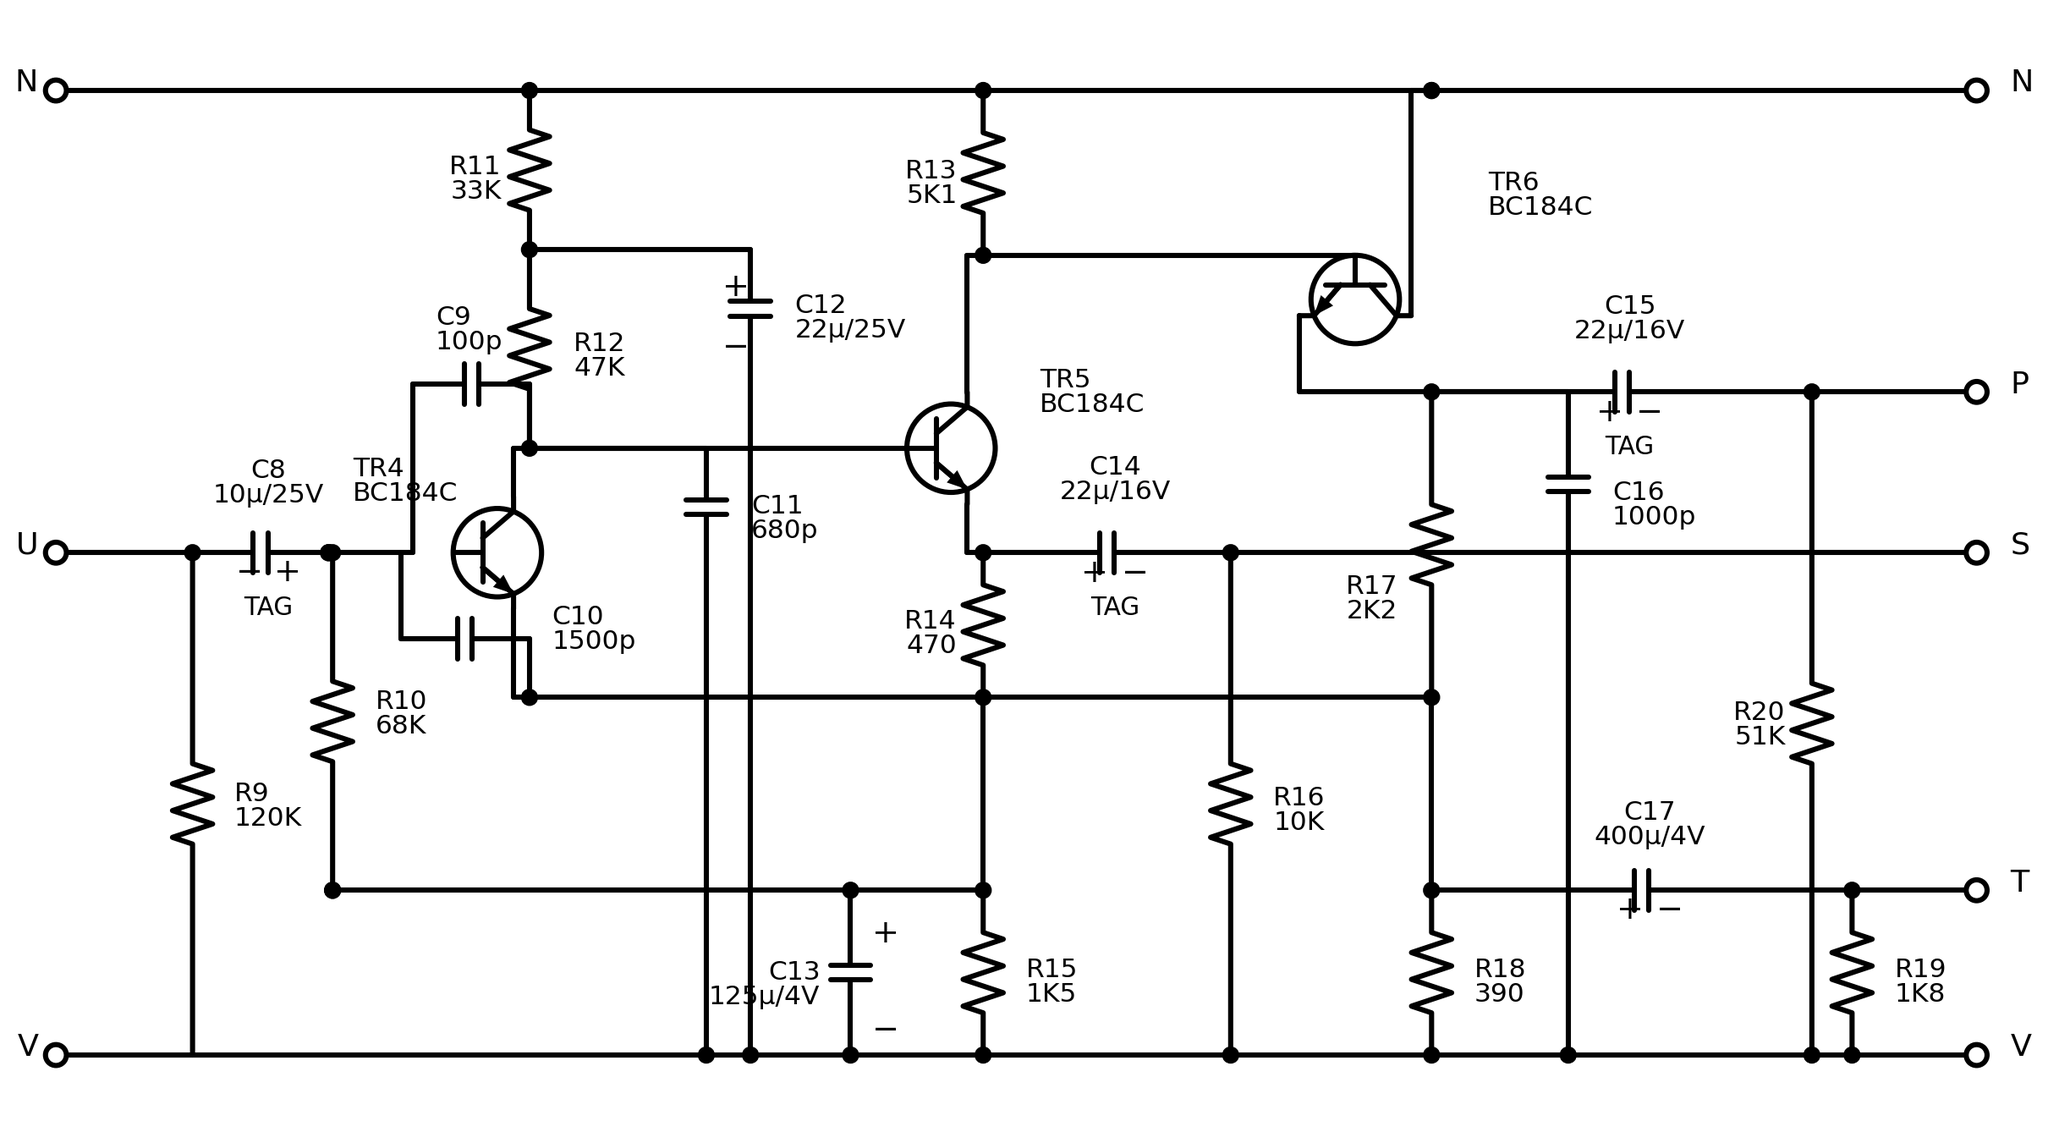

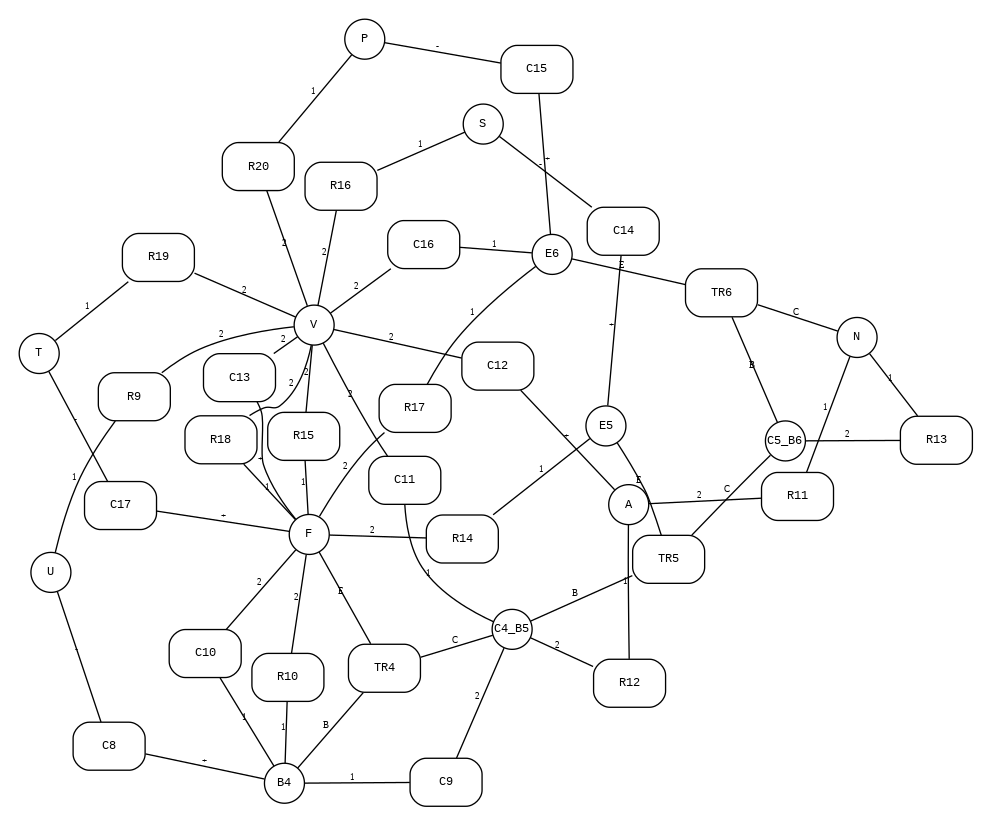

In [7]:
from IPython.display import Image as IPImage
from IPython.display import display

display(IPImage(filename=str(SCHEMATIC_PNG)))
if SHOW_TOPOLOGY_GRAPH:
    display(IPImage(filename=f"{TOPOLOGY_PNG_STEM}.png"))